# Parcial 4

- Julián Divas
- Luis Girón

Se fija la semilla en `2026`, se hacen `10_000` repeticiones por experimento y se imprimen las respuestas con cuatro decimales.

## Ejercicios en Casa

In [1]:
# Importar numpy para usar generación aleatoria y operaciones numéricas.
import numpy as np
# Fijar semilla para reproducibilidad del experimento.
np.random.seed(2026)
# Definir cantidad de repeticiones del experimento.
n_repeticiones = 10000

# ============================================================
# Problema A - Dados
# ============================================================
# Generar n_repeticiones valores enteros uniformes 1..6 para el primer dado.
dado1 = np.random.randint(1, 7, size=n_repeticiones)  # primer dado
# Generar n_repeticiones valores enteros 1..6 para el segundo dado.
dado2 = np.random.randint(1, 7, size=n_repeticiones)  # segundo dado
# Sumar ambos resultados para cada repetición.
suma_dados = dado1 + dado2  # suma entre 2 y 12
# Crear indicador de suma igual a 7 por repetición.
suma_7 = suma_dados == 7  # booleano
# Crear indicador de que al menos uno de los dados es par.
al_menos_un_par = (dado1 % 2 == 0) | (dado2 % 2 == 0)  # booleano
# Estimar la probabilidad empírica de que la suma sea 7.
prob_suma_7 = np.mean(suma_7)  # frecuencia relativa
# Estimar la probabilidad condicional: suma=7 dado al menos un par.
prob_suma_7_dado_par = np.mean(suma_7 & al_menos_un_par) / np.mean(al_menos_un_par)  # condicional empírico
# Valores teóricos para referencia.
prob_suma_7_teorica = 1 / 6  # exacto
prob_suma_7_dado_par_teorica = 2 / 9  # exacto condicional
# Imprimir resultados con cuatro decimales.
print('Problema A - Dados')
print(f'P(suma = 7) = {prob_suma_7:.4f} (valor exacto = {prob_suma_7_teorica:.4f})')
print(f'P(suma = 7 | al menos un dado par) = {prob_suma_7_dado_par:.4f} (valor exacto = {prob_suma_7_dado_par_teorica:.4f})')
print()

Problema A - Dados
P(suma = 7) = 0.1627 (valor exacto = 0.1667)
P(suma = 7 | al menos un dado par) = 0.2164 (valor exacto = 0.2222)



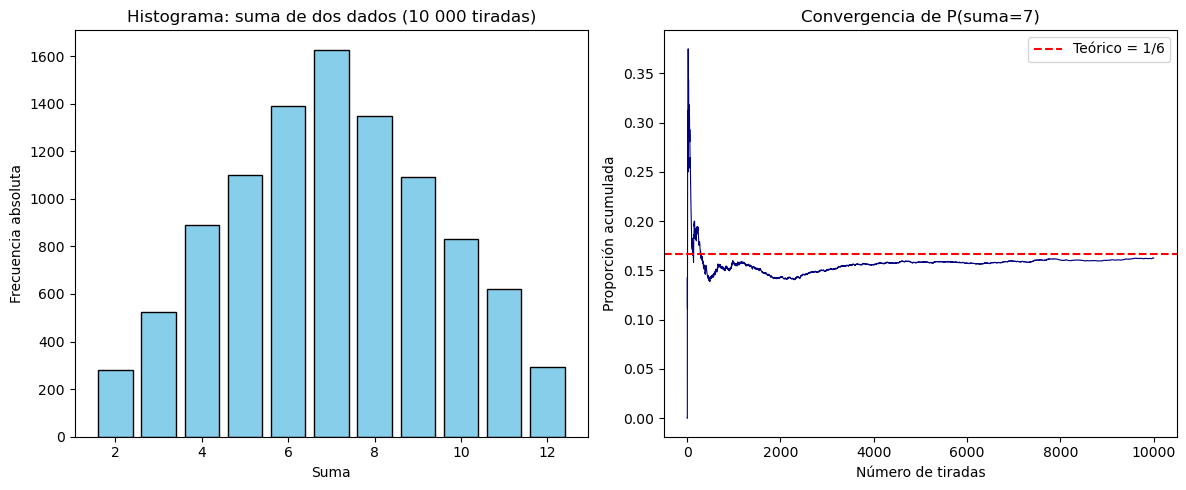

In [12]:
# ============================================================
# Gráficos - Problema A (Dados)
# ============================================================
# Importar matplotlib para graficar.
import matplotlib.pyplot as plt
# Calcular frecuencias de las sumas (2..12) usando numpy.
valores, conteos = np.unique(suma_dados, return_counts=True)
# Preparar figura para dos subplots: histograma y convergencia.
plt.figure(figsize=(12, 5))
# Subplot 1: histograma de la suma de los dos dados.
plt.subplot(1, 2, 1)  # primera de dos columnas
# Graficar barras con las frecuencias absolutas.
plt.bar(valores, conteos, color='skyblue', edgecolor='black')
# Título y etiquetas.
plt.title('Histograma: suma de dos dados (10 000 tiradas)')
plt.xlabel('Suma')
plt.ylabel('Frecuencia absoluta')
# Subplot 2: convergencia de la proporción de suma==7.
plt.subplot(1, 2, 2)  # segunda de dos columnas
# Calcular proporción acumulada de que suma==7.
proporcion_acumulada = np.cumsum(suma_7) / np.arange(1, len(suma_7) + 1)
# Graficar la proporción acumulada.
plt.plot(proporcion_acumulada, lw=0.8, color='navy')
# Dibujar línea horizontal con el valor teórico 1/6.
plt.axhline(1/6, color='red', linestyle='--', label='Teórico = 1/6')
# Etiquetas y título para el subplot de convergencia.
plt.title('Convergencia de P(suma=7)')
plt.xlabel('Número de tiradas')
plt.ylabel('Proporción acumulada')
plt.legend()
# Ajustar espacio entre subplots.
plt.tight_layout()
# Mostrar la figura en pantalla.
plt.show()

In [ ]:
# Importar numpy para usar generación aleatoria y operaciones numéricas.
import numpy as np
# Fijar semilla para reproducibilidad del experimento.
np.random.seed(2026)
# Definir cantidad de repeticiones del experimento.
n_repeticiones = 10000

# ============================================================
# Problema B - Monedas
# ============================================================
# Simular tres monedas independientes: 1=cara, 0=cruz.
monedas = np.random.binomial(n=1, p=0.5, size=(n_repeticiones, 3))  # matriz n x 3
# Contar el número de caras en cada repetición.
caras_por_experimento = np.sum(monedas, axis=1)  # suma por fila
# Estimar P(exactamente 2 caras).
prob_exactamente_2_caras = np.mean(caras_por_experimento == 2)  # frecuencia relativa
# Estimar la esperanza E[X] del número de caras.
esperanza_caras = np.mean(caras_por_experimento)  # promedio empírico
# Valores teóricos para referencia.
prob_exactamente_2_caras_teorica = 3 / 8  # exacto
esperanza_caras_teorica = 3 / 2  # exacto
# Imprimir resultados con cuatro decimales.
print('Problema B - Monedas')
print(f'P(exactamente 2 caras) = {prob_exactamente_2_caras:.4f} (valor exacto = {prob_exactamente_2_caras_teorica:.4f})')
print(f'E[X] = {esperanza_caras:.4f} (valor exacto = {esperanza_caras_teorica:.4f})')
print()

Problema B - Monedas
P(exactamente 2 caras) = 0.3744 (valor exacto = 0.3750)
E[X] = 1.5068 (valor exacto = 1.5000)



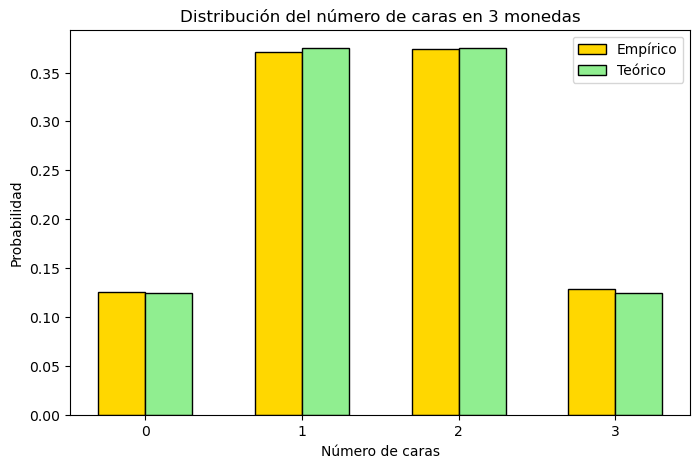

In [14]:
# ============================================================
# Gráficos - Problema B (Monedas)
# ============================================================
# Importar matplotlib para graficar.
import matplotlib.pyplot as plt
# Contar las frecuencias de 0,1,2,3 caras en las simulaciones.
valores_b, conteos_b = np.unique(caras_por_experimento, return_counts=True)
# Calcular probabilidades teóricas de binomial B(3, 0.5) para comparar.
from math import comb
probs_teoricas = [(comb(3, k) * (0.5 ** k) * (0.5 ** (3 - k))) for k in valores_b]
# Crear figura para gráfico de barras comparativo.
plt.figure(figsize=(8, 5))
# Barras con frecuencias relativas observadas.
plt.bar(valores_b - 0.15, conteos_b / n_repeticiones, width=0.3, label='Empírico', color='gold', edgecolor='black')
# Barras con probabilidades teóricas.
plt.bar(valores_b + 0.15, probs_teoricas, width=0.3, label='Teórico', color='lightgreen', edgecolor='black')
# Etiquetas y título.
plt.title('Distribución del número de caras en 3 monedas')
plt.xlabel('Número de caras')
plt.ylabel('Probabilidad')
plt.xticks(valores_b)
plt.legend()
# Mostrar la figura.
plt.show()

In [15]:
# Importar numpy para usar generación aleatoria y operaciones numéricas.
import numpy as np
# Fijar semilla para reproducibilidad del experimento.
np.random.seed(2026)
# Definir cantidad de repeticiones del experimento.
n_repeticiones = 10_000

# ============================================================
# Problema C - Canicas de colores
# ============================================================
# Definir la composición de la caja única: 5 rojas, 3 azules, 2 verdes.
caja_unica = np.array(['roja'] * 5 + ['azul'] * 3 + ['verde'] * 2)  # 10 canicas
# Preparar array booleano para marcar si en cada repetición salieron dos rojas.
ambas_rojas = np.zeros(n_repeticiones, dtype=bool)  # inicializar
# Repetir extracciones sin reemplazo y comprobar ambas rojas.
for i in range(n_repeticiones):
    # Extraer dos canicas sin reemplazo de la caja.
    extraccion = np.random.choice(caja_unica, size=2, replace=False)
    # Marcar si ambas son rojas.
    ambas_rojas[i] = np.all(extraccion == 'roja')
# Estimar probabilidad empírica de que ambas sean rojas.
prob_ambas_rojas = np.mean(ambas_rojas)  # frecuencia relativa
# Valor teórico conocido para comparación.
prob_ambas_rojas_teorica = 2 / 9  # exacto
# Imprimir resultado con cuatro decimales.
print('Problema C - Parte 1')
print(f'P(ambas rojas) = {prob_ambas_rojas:.4f} (valor exacto = {prob_ambas_rojas_teorica:.4f})')
print()
# --- Segunda parte de C: dos cajas y posterior de caja 1 ---
# Definir caja 1: 5 rojas, 3 azules, 2 verdes (misma que arriba).
caja_1 = caja_unica.copy()
# Definir caja 2: 2 rojas, 5 azules, 3 verdes.
caja_2 = np.array(['roja'] * 2 + ['azul'] * 5 + ['verde'] * 3)
# Elegir aleatoriamente una caja por repetición (1 o 2).
caja_elegida = np.random.randint(1, 3, size=n_repeticiones)  # 1 ó 2
# Preparar arrays para registrar origen y si sale (roja, verde).
viene_de_caja_1 = np.zeros(n_repeticiones, dtype=bool)  # origen
resultado_roja_y_verde = np.zeros(n_repeticiones, dtype=bool)  # observación
# Repetir extracciones según caja elegida y registrar eventos.
for i in range(n_repeticiones):
    # Seleccionar la caja según la variable discreta.
    caja_actual = caja_1 if caja_elegida[i] == 1 else caja_2
    # Extraer dos canicas sin reemplazo.
    extraccion = np.random.choice(caja_actual, size=2, replace=False)
    # Registrar si vino de la caja 1.
    viene_de_caja_1[i] = caja_elegida[i] == 1
    # Registrar si la extracción contiene una roja y una verde (en cualquier orden).
    resultado_roja_y_verde[i] = ('roja' in extraccion) and ('verde' in extraccion)
# Filtrar casos donde el resultado fue una roja y una verde.
casos_validos = resultado_roja_y_verde
# Estimar P(Caja 1 | una roja y una verde) empíricamente.
prob_caja_1_dado_rg = np.mean(viene_de_caja_1[casos_validos])  # posterior empírico
# Valor teórico a comparar.
prob_caja_1_dado_rg_teorica = 5 / 8  # exacto
# Imprimir resultado con cuatro decimales.
print('Problema C - Parte 2')
print(f'P(Caja 1 | una roja y una verde) = {prob_caja_1_dado_rg:.4f} (valor exacto = {prob_caja_1_dado_rg_teorica:.4f})')
print()

Problema C - Parte 1
P(ambas rojas) = 0.2245 (valor exacto = 0.2222)

Problema C - Parte 2
P(Caja 1 | una roja y una verde) = 0.6216 (valor exacto = 0.6250)



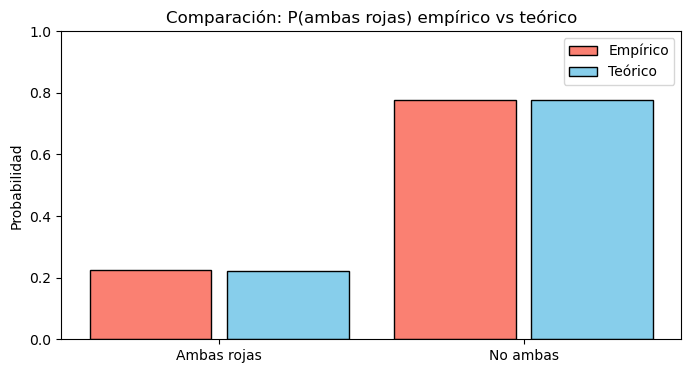

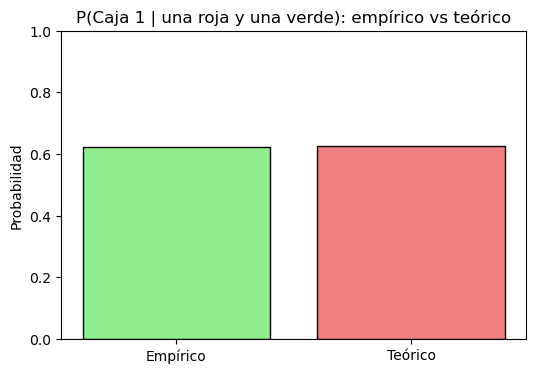

In [16]:
# ============================================================
# Gráficos - Problema C (Canicas)
# ============================================================
# Importar matplotlib para graficar.
import matplotlib.pyplot as plt
# --- Parte 1: probabilidad de ambas rojas ---
# Calcular número de casos donde ambas fueron rojas y donde no.
cuenta_ambas = np.sum(ambas_rojas)  # número de éxitos
cuenta_total = len(ambas_rojas)  # total de repeticiones
# Preparar datos para barra comparativa (empírico vs teórico).
valores = ['Ambas rojas', 'No ambas']
empirico = [cuenta_ambas / cuenta_total, 1 - (cuenta_ambas / cuenta_total)]
teorico = [2/9, 1 - 2/9]
# Graficar barras comparativas.
plt.figure(figsize=(8, 4))
plt.bar([0, 1], empirico, width=0.4, label='Empírico', color='salmon', edgecolor='black')
plt.bar([0.45, 1.45], teorico, width=0.4, label='Teórico', color='skyblue', edgecolor='black')
plt.xticks([0.225, 1.225], valores)
plt.ylim(0, 1)
plt.title('Comparación: P(ambas rojas) empírico vs teórico')
plt.ylabel('Probabilidad')
plt.legend()
plt.show()

# --- Parte 2: posterior P(Caja1 | roja+verde) ---
# Graficar comparación entre el posterior empírico y el teórico.
plt.figure(figsize=(6, 4))
plt.bar(['Empírico', 'Teórico'], [prob_caja_1_dado_rg, prob_caja_1_dado_rg_teorica], color=['lightgreen', 'lightcoral'], edgecolor='black')
plt.ylim(0, 1)
plt.title('P(Caja 1 | una roja y una verde): empírico vs teórico')
plt.ylabel('Probabilidad')
plt.show()

In [17]:
# Importar numpy para usar generación aleatoria y operaciones numéricas.
import numpy as np
# Fijar semilla para reproducibilidad del experimento.
np.random.seed(2026)
# Definir cantidad de repeticiones del experimento.
n_repeticiones = 10_000

# ============================================================
# Problema D - Cartas
# ============================================================
# Construir un mazo simplificado: 4 'as' y 48 'no_as'.
mazo = np.array(['as'] * 4 + ['no_as'] * 48)  # 52 cartas
# Arrays para registrar eventos en cada repetición.
ambos_ases = np.zeros(n_repeticiones, dtype=bool)  # indicador de dos ases
primera_carta_as = np.zeros(n_repeticiones, dtype=bool)  # A
segunda_carta_as = np.zeros(n_repeticiones, dtype=bool)  # B
# Repetir extracciones sin reemplazo para dos cartas.
for i in range(n_repeticiones):
    # Extraer dos cartas sin reemplazo desde el mazo.
    extraccion = np.random.choice(mazo, size=2, replace=False)
    # Registrar si ambas son ases.
    ambos_ases[i] = np.all(extraccion == 'as')
    # Registrar si la primera carta es as.
    primera_carta_as[i] = extraccion[0] == 'as'
    # Registrar si la segunda carta es as.
    segunda_carta_as[i] = extraccion[1] == 'as'
# Estimar probabilidades empíricas.
prob_ambos_ases = np.mean(ambos_ases)  # P(A y B)
prob_A = np.mean(primera_carta_as)  # P(A)
prob_B = np.mean(segunda_carta_as)  # P(B)
# Producto empírico P(A)P(B) para comparar.
producto_probabilidades = prob_A * prob_B
# Valores teóricos conocidos para comparación.
prob_ambos_ases_teorica = 1 / 221  # exacto para dos ases sin reemplazo
producto_probabilidades_teorica = 1 / 169  # (4/52)*(4/52) si fueran independientes
# Determinar independencia empíricamente (cerca del producto).
eventos_independientes = np.isclose(prob_ambos_ases, producto_probabilidades, atol=1e-4)
# Imprimir resultados con cuatro decimales.
print('Problema D - Cartas')
print(f'P(ambas ases) = {prob_ambos_ases:.4f} (valor exacto = {prob_ambos_ases_teorica:.4f})')
print(f'P(A) * P(B) = {producto_probabilidades:.4f} (valor exacto = {producto_probabilidades_teorica:.4f})')
print(f'Los eventos son independientes: {eventos_independientes}')
print()

Problema D - Cartas
P(ambas ases) = 0.0041 (valor exacto = 0.0045)
P(A) * P(B) = 0.0065 (valor exacto = 0.0059)
Los eventos son independientes: False



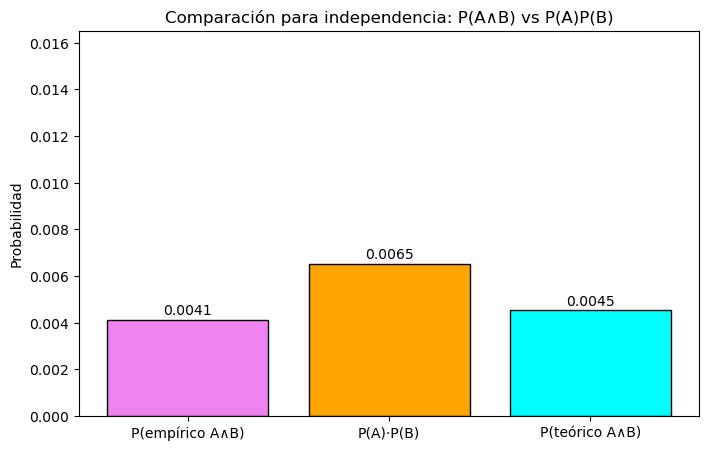

In [18]:
# ============================================================
# Gráficos - Problema D (Cartas)
# ============================================================
# Importar matplotlib para graficar.
import matplotlib.pyplot as plt
# Preparar valores para comparar: empírico P(A∧B), producto P(A)P(B), y teórico P(A∧B).
valores = ['P(empírico A∧B)', 'P(A)·P(B)', 'P(teórico A∧B)']
empirico = [prob_ambos_ases, producto_probabilidades, prob_ambos_ases_teorica]
# Graficar barras y anotar los valores numéricos.
plt.figure(figsize=(8, 5))
bars = plt.bar(valores, empirico, color=['violet', 'orange', 'cyan'], edgecolor='black')
# Anotar cada barra con su valor hasta 4 decimales.
for bar, val in zip(bars, empirico):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.0001, f'{val:.4f}', ha='center', va='bottom')
# Título y etiquetas.
plt.title('Comparación para independencia: P(A∧B) vs P(A)P(B)')
plt.ylim(0, max(empirico) + 0.01)
plt.ylabel('Probabilidad')
plt.show()